# Configuración previa

## Importación de librerías

In [51]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import seaborn

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Dense, Embedding, LSTM, GRU, SimpleRNN, Bidirectional, Flatten, Input, Dropout,
    Conv2D, MaxPooling2D, GlobalMaxPooling2D, GlobalAveragePooling2D, BatchNormalization,
    AveragePooling2D
)
from tensorflow.keras.models import Sequential
import random

import tensorflow as tf

from collections import Counter

from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Replicabilidad

In [4]:
seed = 0
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

## GPU

In [5]:
if tf.config.list_physical_devices('GPU'):
    print("GPU is available")
else:
    print("GPU is not available")

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        tf.config.experimental.set_virtual_device_configuration(
            physical_devices[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=4096)]
        )
        print("GPU configured")
    except RuntimeError as e:
        print(e)

GPU is not available


E0000 00:00:1742816737.323537    4811 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1742816737.324618    4811 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Comprobación de estructura de las imágenes

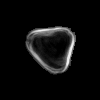

In [6]:
sample = Image.open("data/Tipo_A_Kunzea/Kunzea_12.png")
sample

In [7]:
np.max(np.array(sample)), np.array(sample).shape, np.array(sample)

(np.uint8(241),
 (100, 100),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

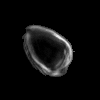

In [8]:
sample = Image.open("data/Tipo_B_Lepto/Lepto_50.png")
sample

In [9]:
np.max(np.array(sample)), np.array(sample).shape, np.array(sample)

(np.uint8(242),
 (100, 100),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

# Carga y preprocesamiento

## Carga

### Datos

In [10]:
directory_A = './data/Tipo_A_Kunzea'
directory_B = './data/Tipo_B_Lepto'


files_A = os.listdir(directory_A)
files_B = os.listdir(directory_B)


if not (len(files_A) == len(files_B) == 1200):
    raise Exception("Error in files. Check the filespath.")


lists_A = []
lists_B = []

for index in range(1200):
    temp_A = Image.open(os.path.join(directory_A, files_A[index]))
    lists_A.append(np.array(temp_A) / 255)
    
    temp_B = Image.open(os.path.join(directory_B, files_B[index]))
    lists_B.append(np.array(temp_B) / 255)



images_A = np.array(lists_A).reshape(-1, 100, 100, 1)
images_B = np.array(lists_B).reshape(-1, 100, 100, 1)

images_A.shape, images_B.shape

((1200, 100, 100, 1), (1200, 100, 100, 1))

In [11]:
data = np.concatenate((images_A, images_B))
labels = np.concatenate((np.full(1200, 'Tipo A - Kunzea'), np.full(1200, 'Tipo B - Lepto')))

data.shape

(2400, 100, 100, 1)

### Etiquetas

In [12]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

## Preprocesamiento

### División de conjuntos

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(data, labels_encoded, test_size=0.30, stratify=labels_encoded, random_state=seed)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed)


X_train.shape, X_val.shape, X_test.shape

((1680, 100, 100, 1), (360, 100, 100, 1), (360, 100, 100, 1))

In [14]:
print(Counter(y_train).most_common())
print(Counter(y_val).most_common())
print(Counter(y_test).most_common())

[(np.int64(1), 840), (np.int64(0), 840)]
[(np.int64(0), 180), (np.int64(1), 180)]
[(np.int64(1), 180), (np.int64(0), 180)]


### Data Augmentation

In [15]:
datagen = ImageDataGenerator(
    rotation_range=10,         # Rotación máxima de 10 grados
    width_shift_range=0.05,     # Desplazamiento horizontal del 10%
    height_shift_range=0.05,    # Desplazamiento vertical del 10%
    zoom_range=0.1,            # Zoom entre 0.9x y 1.1x
    # brightness_range=[0.8, 1.2],  # Cambio de brillo entre 0.8 y 1.2
    # horizontal_flip=True,
    fill_mode='reflect'        # Rellena áreas vacías con el píxel más cercano # nearest, reflect
)

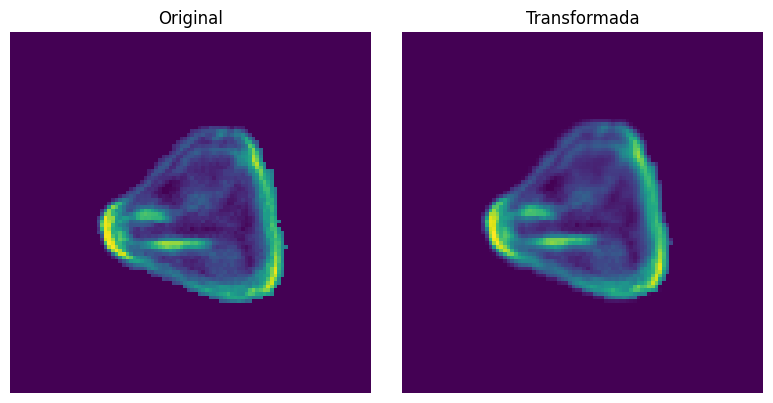

In [16]:
original_image = X_train[0]

transformed_image = datagen.random_transform(original_image)

# Visualizar
plt.figure(figsize=(8, 4))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(original_image.squeeze())#, cmap='gray') 
plt.title("Original")
plt.axis("off")

# Imagen transformada
plt.subplot(1, 2, 2)
plt.imshow(transformed_image.squeeze())#, cmap='gray')
plt.title("Transformada")
plt.axis("off")

plt.tight_layout()
plt.show()

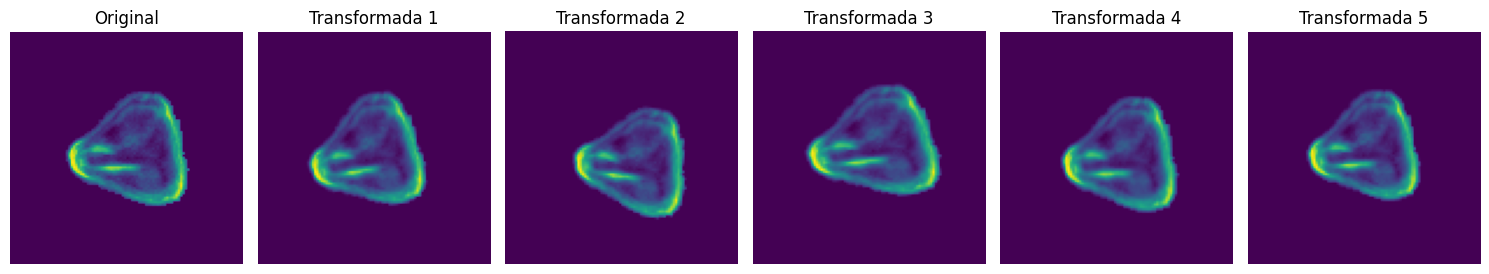

In [17]:
original_image = X_train[0]

augmented_images = [datagen.random_transform(original_image) for _ in range(5)]

# Crear figura con 6 columnas (original + 5 transformaciones)
plt.figure(figsize=(15, 3))

# Mostrar original
plt.subplot(1, 6, 1)
plt.imshow(original_image.squeeze())
plt.title("Original")
plt.axis("off")

# Mostrar transformaciones
for i in range(5):
    plt.subplot(1, 6, i + 2)
    plt.imshow(augmented_images[i].squeeze())
    plt.title(f"Transformada {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import numpy as np

def generate_samples(X_train, y_train, datagen=datagen, n_samples=10):

    syntetic_samples = []
    
    for image in X_train:  
        images_list = [datagen.random_transform(image) for _ in range(n_samples)]
        syntetic_samples.extend(images_list)
    
    data = np.concatenate((X_train, syntetic_samples))
    labels = np.concatenate((y_train, np.repeat(y_train, n_samples)))

    return data, labels

In [19]:
X_train_augmented, y_train_augmented = generate_samples(X_train, y_train)

X_train_augmented.shape, y_train_augmented.shape

((18480, 100, 100, 1), (18480,))

# Funciones

## Funciones de visualización

In [20]:
def plot_history(history):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

In [21]:
def plot_confusion_matrix(test_labels, predictions):
    cm = confusion_matrix(test_labels, predictions)

    plt.figure(figsize=(5, 4))
    seaborn.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.title('Matriz de confusión')
    plt.ylabel('Etiqueta verdadera')
    plt.xlabel('Etiqueta predicha')
    plt.show()

## Funciones de evaluación

In [22]:
def training(model, train_data=X_train, train_labels=y_train, val_data=X_val, val_labels=y_val, epochs=150, batch_size=128):

    optimizer = Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['acc'])


    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            min_delta=0.005,
            restore_best_weights=True,
            mode='min',
            verbose=1
        )
    ]

    history = model.fit(
        train_data,
        np.array(train_labels),
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(val_data, val_labels),
        callbacks=callbacks,
        verbose=0
    )

    return model, history

In [33]:
def evaluate_predictions(model, test_data=X_test, test_labels=y_test):
    predictions = model.predict(test_data, verbose=0)
    predictions = np.round(predictions).astype(int).flatten()
    predictions = le.inverse_transform(predictions)
    true_labels = le.inverse_transform(test_labels)

    print(classification_report(true_labels, predictions, zero_division=0))
    # plot_confusion_matrix(true_labels, predictions)

    print('\n\t\t+-----------------------+')
    print('\t\t| Test accuracy:', round(accuracy_score(true_labels, predictions), 4), '|')
    print('\t\t+-----------------------+\n')

    return predictions

In [24]:
def train_and_evaluate(model, train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, graph=True):
    model, history = training(model, train_data=train_data, train_labels=train_labels)

    predictions = evaluate_predictions(model, test_data, test_labels)
    if graph:
        print(model.summary())
        plot_history(history)
        plot_confusion_matrix(le.inverse_transform(test_labels), predictions)

    return model

In [25]:
def evaluation(model, history, test_data=X_test, test_labels=y_test, graph=True):
    predictions = evaluate_predictions(model, test_data, test_labels)
    if graph:
        print(model.summary())
        plot_history(history)
        plot_confusion_matrix(le.inverse_transform(test_labels), predictions)

# Arquitecturas

## NET-1

Epoch 101: early stopping
Restoring model weights from the end of the best epoch: 86.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.81      0.89      0.85       180
 Tipo B - Lepto       0.88      0.79      0.83       180

       accuracy                           0.84       360
      macro avg       0.85      0.84      0.84       360
   weighted avg       0.85      0.84      0.84       360


		+-----------------------+
		| Test accuracy: 0.8417 |
		+-----------------------+



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │        10,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,005 (117.21 KB)

 Trainable params: 10,001 (39.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,004 (78.14 KB)

None


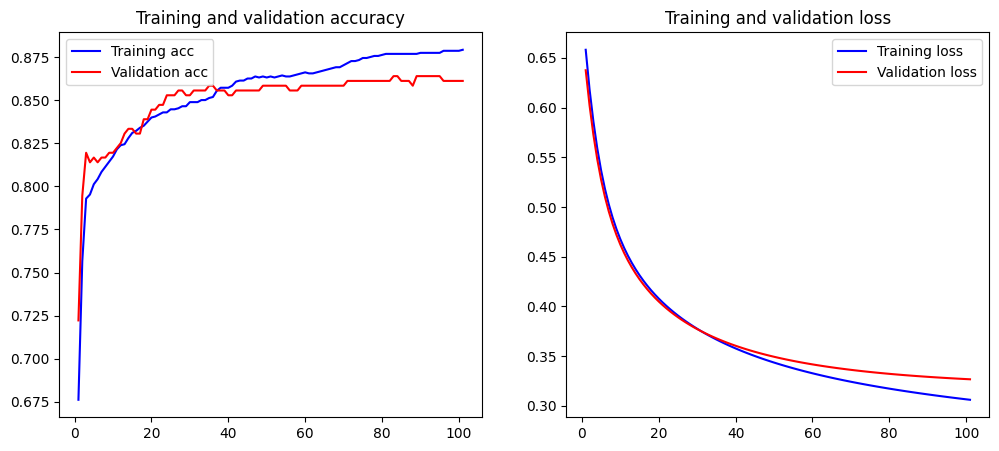

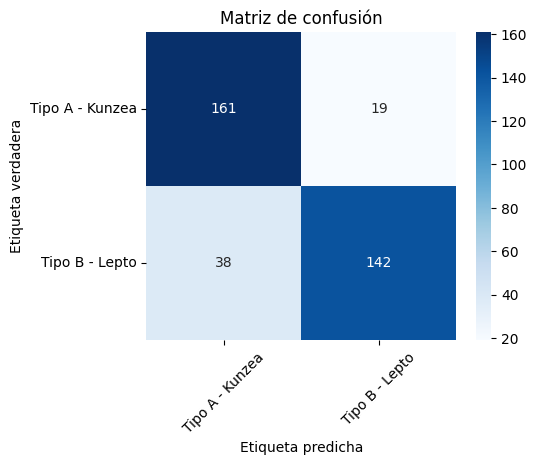

In [35]:
model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(1, activation='sigmoid') 
])

model = train_and_evaluate(model)

2025-03-24 12:12:26.450958: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 739200000 exceeds 10% of free system memory.


Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 3.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.70      0.94      0.80       180
 Tipo B - Lepto       0.91      0.59      0.71       180

       accuracy                           0.76       360
      macro avg       0.80      0.76      0.76       360
   weighted avg       0.80      0.76      0.76       360


		+-----------------------+
		| Test accuracy: 0.7639 |
		+-----------------------+



Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │        10,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,005 (117.21 KB)

 Trainable params: 10,001 (39.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,004 (78.14 KB)

None


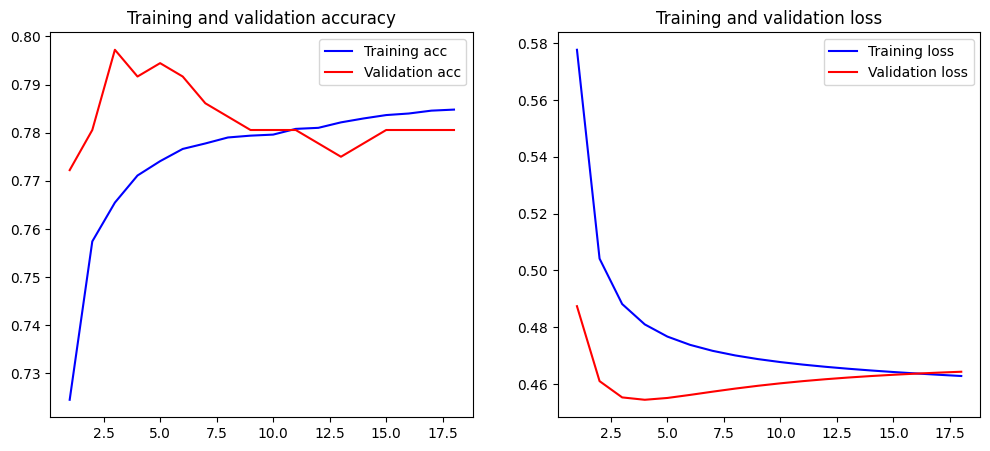

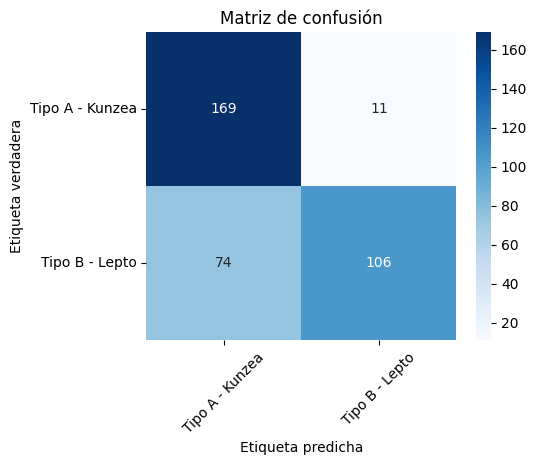

In [36]:
model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(1, activation='sigmoid') 
])

model = train_and_evaluate(model, train_data=X_train_augmented, train_labels=y_train_augmented)

## NET-2

Epoch 96: early stopping
Restoring model weights from the end of the best epoch: 81.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.88      0.94      0.91       180
 Tipo B - Lepto       0.94      0.87      0.90       180

       accuracy                           0.91       360
      macro avg       0.91      0.91      0.91       360
   weighted avg       0.91      0.91      0.91       360


		+-----------------------+
		| Test accuracy: 0.9056 |
		+-----------------------+



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,920,389 (7.33 MB)

 Trainable params: 640,129 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,280,260 (4.88 MB)

None


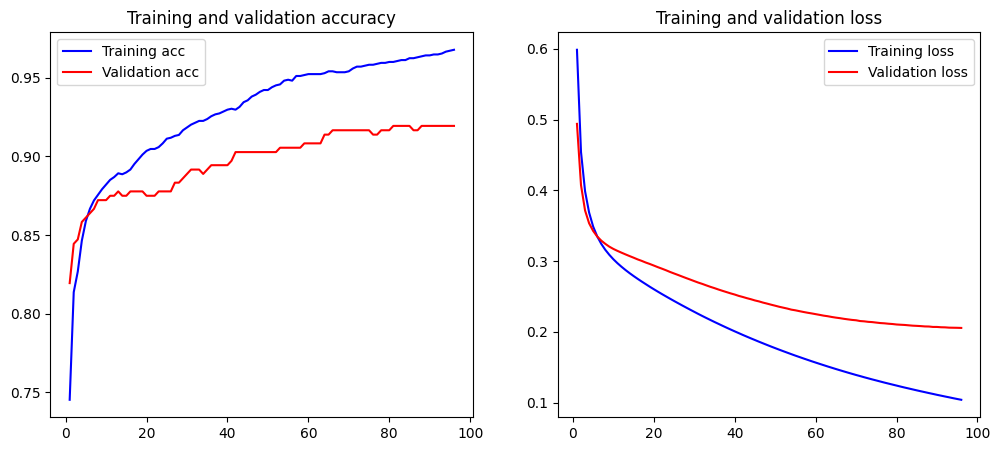

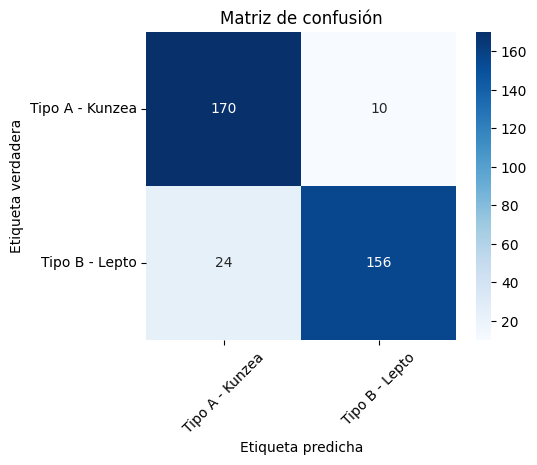

In [37]:
model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

model = train_and_evaluate(model)

Epoch 52: early stopping
Restoring model weights from the end of the best epoch: 37.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.89      0.95      0.92       180
 Tipo B - Lepto       0.95      0.88      0.91       180

       accuracy                           0.91       360
      macro avg       0.92      0.91      0.91       360
   weighted avg       0.92      0.91      0.91       360


		+-----------------------+
		| Test accuracy: 0.9139 |
		+-----------------------+



Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,865,349 (14.75 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,576,900 (9.83 MB)

None


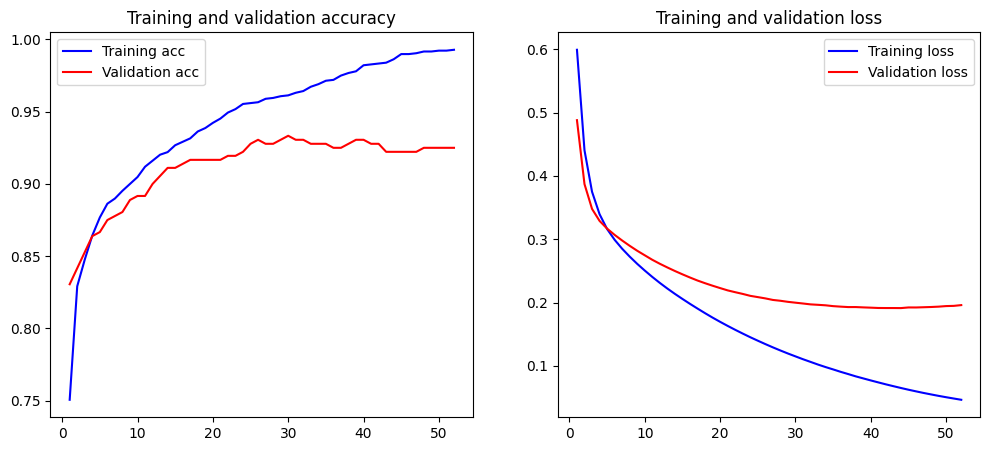

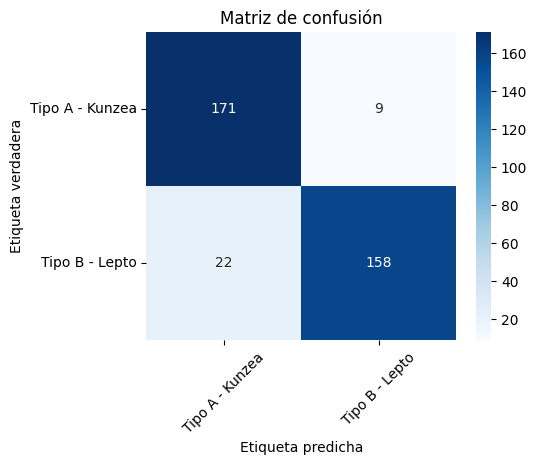

In [38]:
model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

model = train_and_evaluate(model)

Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 28.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.90      0.94      0.92       180
 Tipo B - Lepto       0.94      0.90      0.92       180

       accuracy                           0.92       360
      macro avg       0.92      0.92      0.92       360
   weighted avg       0.92      0.92      0.92       360


		+-----------------------+
		| Test accuracy: 0.9222 |
		+-----------------------+



Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,804,421 (29.77 MB)

 Trainable params: 2,601,473 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,202,948 (19.85 MB)

None


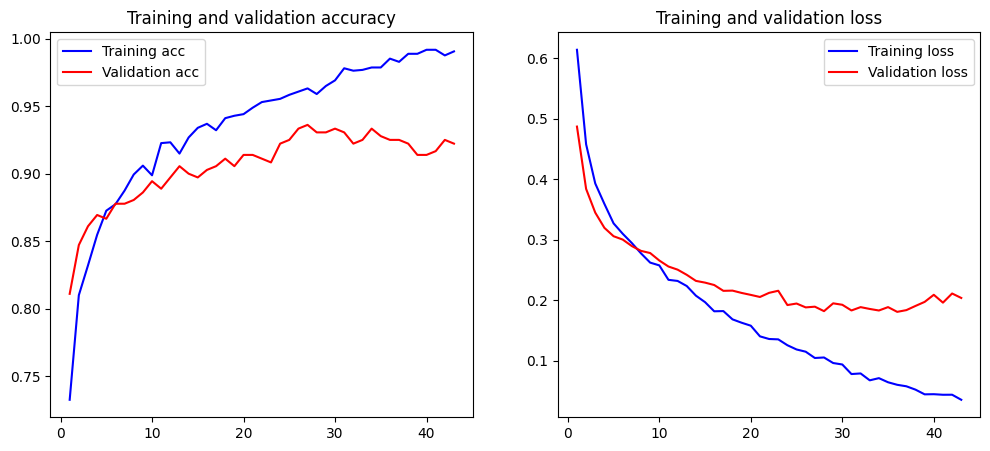

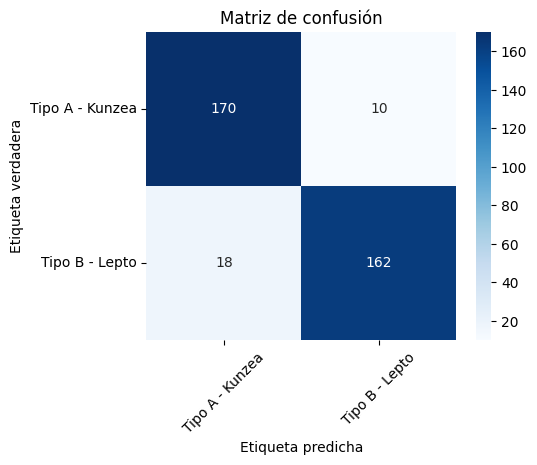

In [39]:
model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

model = train_and_evaluate(model)

Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 21.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.88      0.97      0.92       180
 Tipo B - Lepto       0.96      0.87      0.91       180

       accuracy                           0.92       360
      macro avg       0.92      0.92      0.92       360
   weighted avg       0.92      0.92      0.92       360


		+-----------------------+
		| Test accuracy: 0.9167 |
		+-----------------------+



Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,804,421 (29.77 MB)

 Trainable params: 2,601,473 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,202,948 (19.85 MB)

None


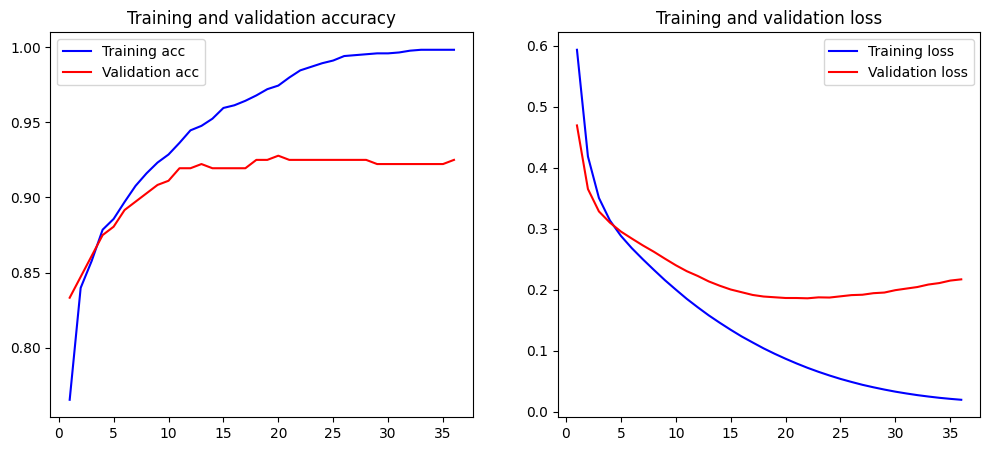

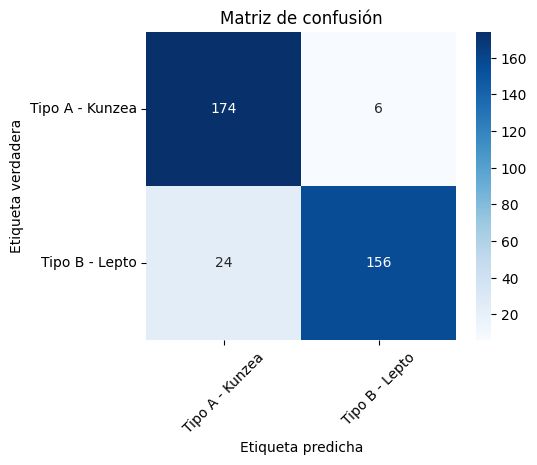

In [40]:
model = Sequential([
    Input(shape=(100, 100, 1)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

model = train_and_evaluate(model)

## NET-3

Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 3.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.89      0.94      0.92       180
 Tipo B - Lepto       0.94      0.89      0.91       180

       accuracy                           0.91       360
      macro avg       0.91      0.91      0.91       360
   weighted avg       0.91      0.91      0.91       360


		+-----------------------+
		| Test accuracy: 0.9139 |
		+-----------------------+



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001,797 (30.52 MB)

 Trainable params: 2,667,265 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,334,532 (20.35 MB)

None


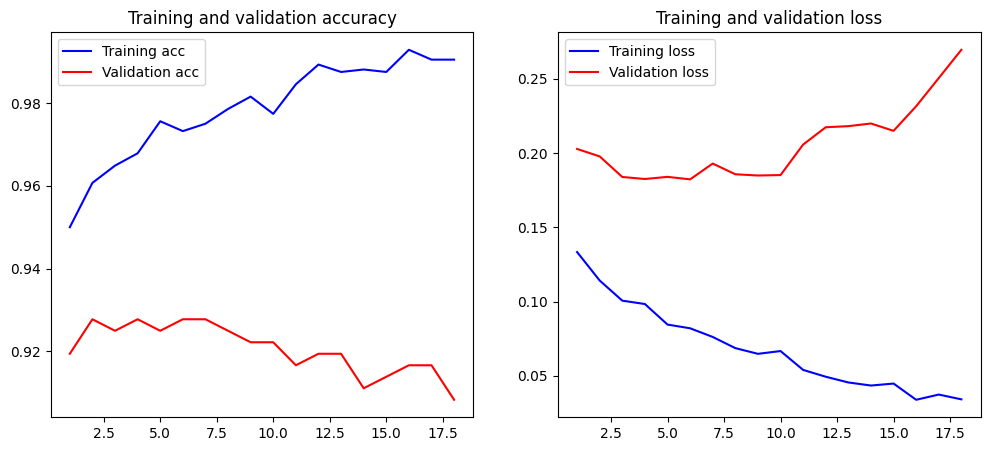

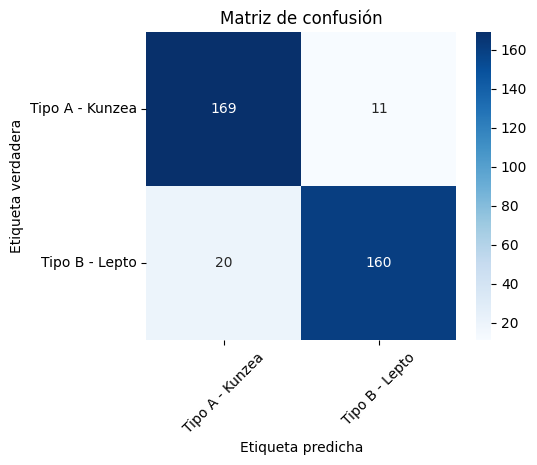

In [ ]:
model_cnn = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model)

Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 2.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.93      0.93      0.93       180
 Tipo B - Lepto       0.93      0.93      0.93       180

       accuracy                           0.93       360
      macro avg       0.93      0.93      0.93       360
   weighted avg       0.93      0.93      0.93       360


		+-----------------------+
		| Test accuracy: 0.9306 |
		+-----------------------+



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001,797 (30.52 MB)

 Trainable params: 2,667,265 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,334,532 (20.35 MB)

None


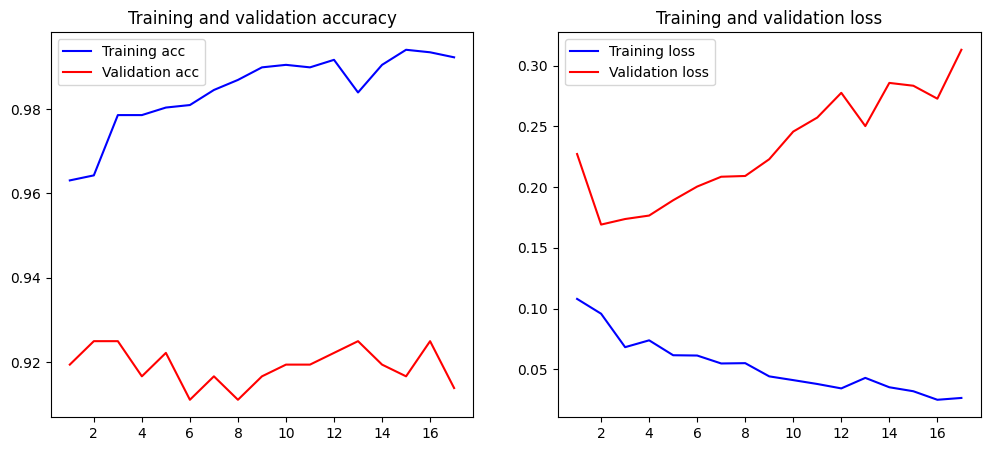

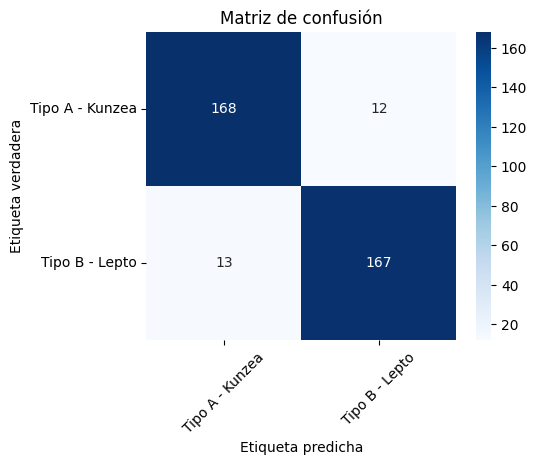

In [46]:
model_cnn = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (5, 5), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (5, 5), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model)

Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 1.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.92      0.95      0.93       180
 Tipo B - Lepto       0.95      0.92      0.93       180

       accuracy                           0.93       360
      macro avg       0.93      0.93      0.93       360
   weighted avg       0.93      0.93      0.93       360


		+-----------------------+
		| Test accuracy: 0.9333 |
		+-----------------------+



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001,797 (30.52 MB)

 Trainable params: 2,667,265 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,334,532 (20.35 MB)

None


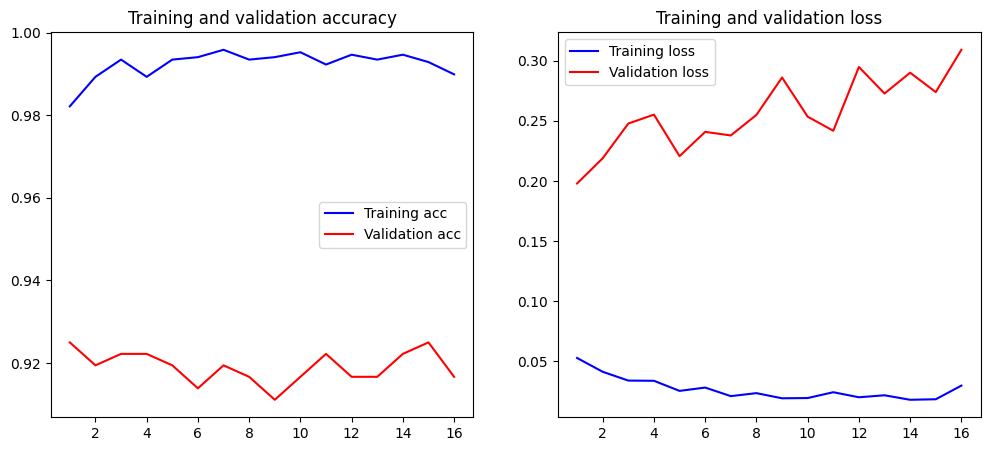

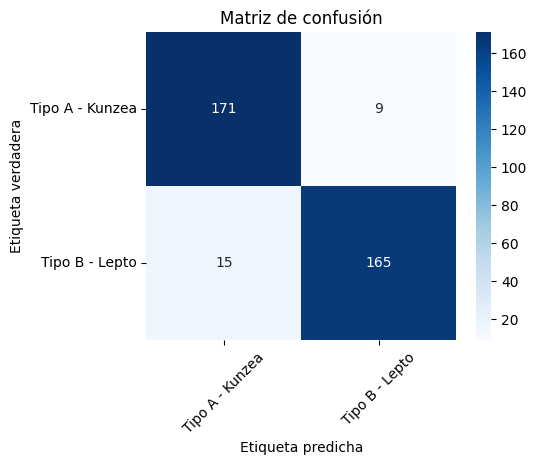

In [53]:
model_cnn = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (5, 5), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (5, 5), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (5, 5), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model)

Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 6.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.95      0.93      0.94       180
 Tipo B - Lepto       0.93      0.96      0.95       180

       accuracy                           0.94       360
      macro avg       0.94      0.94      0.94       360
   weighted avg       0.94      0.94      0.94       360


		+-----------------------+
		| Test accuracy: 0.9444 |
		+-----------------------+



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001,797 (30.52 MB)

 Trainable params: 2,667,265 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,334,532 (20.35 MB)

None


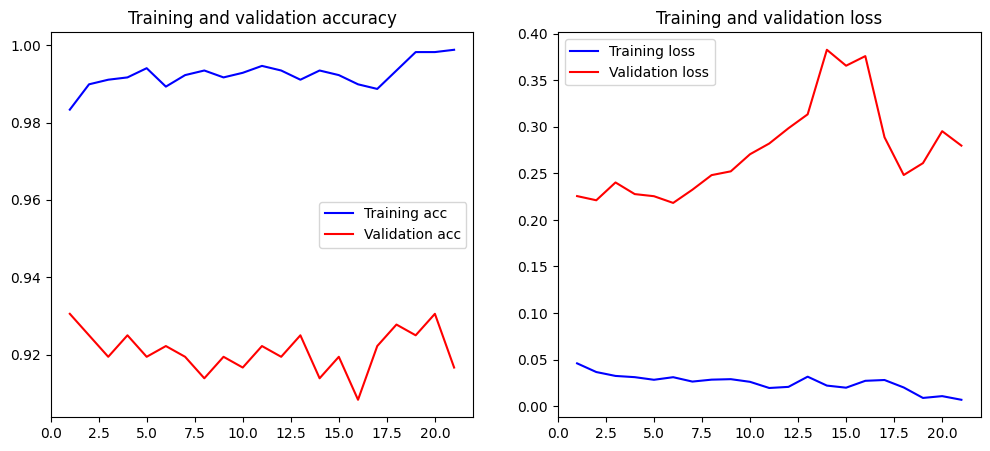

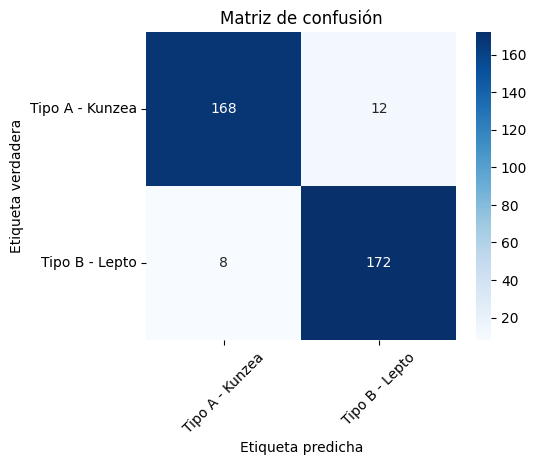

In [54]:
model_cnn = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (5, 5), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model)

Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 4.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.95      0.93      0.94       180
 Tipo B - Lepto       0.93      0.96      0.95       180

       accuracy                           0.94       360
      macro avg       0.94      0.94      0.94       360
   weighted avg       0.94      0.94      0.94       360


		+-----------------------+
		| Test accuracy: 0.9444 |
		+-----------------------+



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001,797 (30.52 MB)

 Trainable params: 2,667,265 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,334,532 (20.35 MB)

None


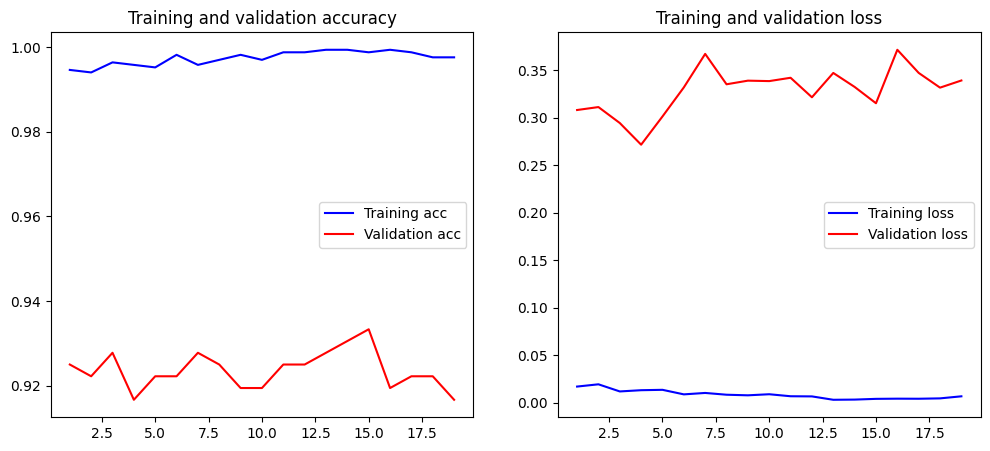

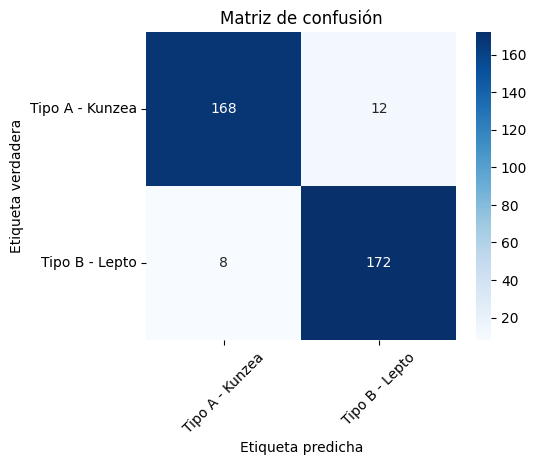

In [59]:
model_cnn = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (5, 5), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (5, 5), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model)

Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 4.
                 precision    recall  f1-score   support

Tipo A - Kunzea       0.92      0.95      0.94       180
 Tipo B - Lepto       0.95      0.92      0.94       180

       accuracy                           0.94       360
      macro avg       0.94      0.94      0.94       360
   weighted avg       0.94      0.94      0.94       360


		+-----------------------+
		| Test accuracy: 0.9361 |
		+-----------------------+



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001,797 (30.52 MB)

 Trainable params: 2,667,265 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,334,532 (20.35 MB)

None


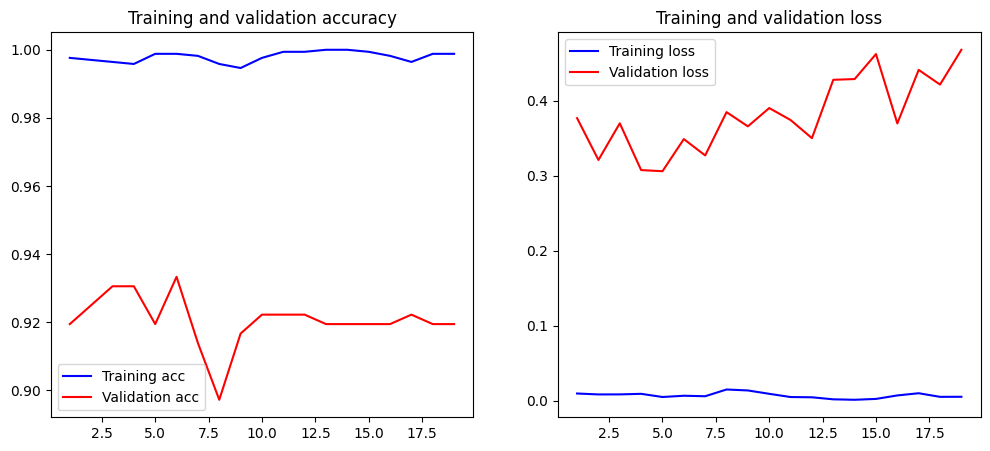

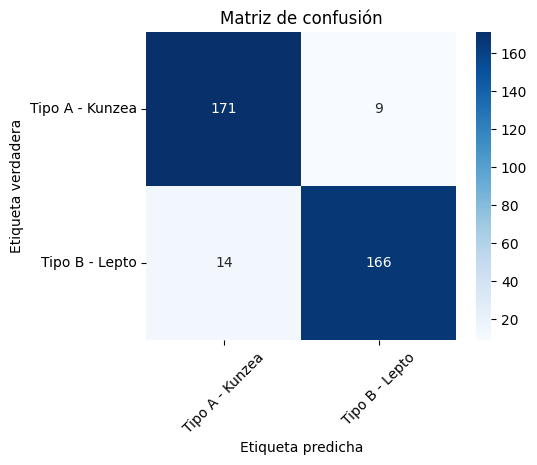

In [61]:
model_cnn = Sequential([
    Input(shape=(100, 100, 1)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1, activation='sigmoid')
])

model = train_and_evaluate(model)